<a href="https://colab.research.google.com/github/Knchna/ICT_AI-ML/blob/main/Jul_13_Intermediate_Assessment_2_Supervised_Learning_on_Heart_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split

# classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# regression


# Reading Dataset

In [67]:
filepath = "/content/drive/MyDrive/ICT_AIML Class/Datasets/heart_disease.csv"

In [68]:
df_heart = pd.read_csv(filepath)
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# EDA

In [69]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [70]:
# Inference:
  # No missing values are there
  # all values are encoded as numerical, including conceptually categorical ones

In [71]:
df_heart.shape

(1025, 14)

In [72]:
df_heart.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

In [73]:
# Column Details:
'''
1. 'age'                                      : Age of the individual
2. 'sex'                                      : Gender of the individual          (0 = female, 1 = male)
3. chest pain type              ['cp']        : Type of chest pain                (4 categories: 0-3)
4. resting blood pressure       ['trestbps']  : Resting blood pressure (in mm Hg)
5. serum cholesterol            ['chol']      : Cholesterol level (in mg/dl)                                  [Target for regression]
6. fasting blood sugar          ['fbs']       : Fasting blood sugar > 120 mg/dl   (1 = true, 0 = false)
7. resting electrocardiographic ['restecg']   : ECG results
                      results                  (0 = normal, 1 = ST-T abnormality, 2 = probable/definite left ventricular hypertrophy)
8. maximum heart rate achieved  ['thalach']   : cont. num values
9. exercise induced angina      ['exang']     : Exercise-induced chest pain       (1 = yes, 0 = no)
10. 'oldpeak'                                 : ST depression induced by exercise relative to rest
11. 'slope'                                   : The slope of the peak exercise ST segment     (0-2)
12. number of major vessels     ['ca']        : Number of major vessels           (0-3) colored by fluoroscopy
13. 'thal'                                    : Type of thalassemia               (0 = normal, 1 = fixed defect, 2 = reversible defect)
14. 'target'                                  : Presence of heart disease         (1 = Yes, 0 = No)           [Target for classifcation]
'''

"\n1. 'age'                                      : Age of the individual\n2. 'sex'                                      : Gender of the individual          (0 = female, 1 = male)\n3. chest pain type              ['cp']        : Type of chest pain                (4 categories: 0-3)\n4. resting blood pressure       ['trestbps']  : Resting blood pressure (in mm Hg)\n5. serum cholesterol            ['chol']      : Cholesterol level (in mg/dl)                                  [Target for regression]   \n6. fasting blood sugar          ['fbs']       : Fasting blood sugar > 120 mg/dl   (1 = true, 0 = false)\n7. resting electrocardiographic ['restecg']   : ECG results \n                      results                  (0 = normal, 1 = ST-T abnormality, 2 = probable/definite left ventricular hypertrophy)\n8. maximum heart rate achieved  ['thalach']   : cont. num values                               \n9. exercise induced angina      ['exang']     : Exercise-induced chest pain       (1 = yes, 0 = n

In [74]:
# No redundant columns visible from this to drop

In [75]:
# printing descriptive statistics summary

df_heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [76]:
# printing unique values

for i in df_heart.columns:
  print(f"Value counts in column {i} is: {df_heart[i].value_counts()} \n")
  print(f"No of unique values in column {i} is: {df_heart[i].nunique()} \n")
  print("*************************************************")

Value counts in column age is: age
58    68
57    57
54    53
59    46
52    43
56    39
51    39
62    37
60    37
44    36
64    34
41    32
63    32
61    31
67    31
55    30
65    27
42    26
43    26
53    26
45    25
66    25
46    23
48    23
50    21
47    18
49    17
35    15
70    14
39    14
38    12
68    12
71    11
40    11
69     9
34     6
37     6
29     4
76     3
77     3
74     3
Name: count, dtype: int64 

No of unique values in column age is: 41 

*************************************************
Value counts in column sex is: sex
1    713
0    312
Name: count, dtype: int64 

No of unique values in column sex is: 2 

*************************************************
Value counts in column cp is: cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64 

No of unique values in column cp is: 4 

*************************************************
Value counts in column trestbps is: trestbps
120    128
130    123
140    107
110     64
150     55
138     45
128

# Data Cleaning

# **Classification**

In [77]:
df_class = df_heart.copy()    # For classification
df_reg = df_heart.copy()      # For regression

In [78]:
# For classification

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

# In cat_cols :
  # nominal cols -  'cp', 'restecg', 'thal'       -> 'cp' doesn't show severity of chest pain, instead it shows type
                                                      # => Needs OHE
  # count col -  'ca'                             -> actually a discrete numerical col, treated as cat_col due to only 4 nunique
                                                      # used as is, because it's essentially numerical column
  # ordinal cols  - 'slope'                       -> 'slope' shows slope type like up, flat and down which has ranking
                                                      # => already encoded
  # binary cols - 'sex', 'fbs', 'exang'           => Already encoded properly


target_col = 'target'   # already encoded
# Presence of heart disease (1 = Yes, 0 = No)    => Binary Classification

In [79]:
for column in cat_cols:
  print(column)
  print(df_class[column].unique())
  print(df_class[column].nunique())
  print("\n")

sex
[1 0]
2


cp
[0 1 2 3]
4


fbs
[0 1]
2


restecg
[1 0 2]
3


exang
[0 1]
2


slope
[2 0 1]
3


ca
[2 0 1 3 4]
5


thal
[3 2 1 0]
4




## Outlier Handling

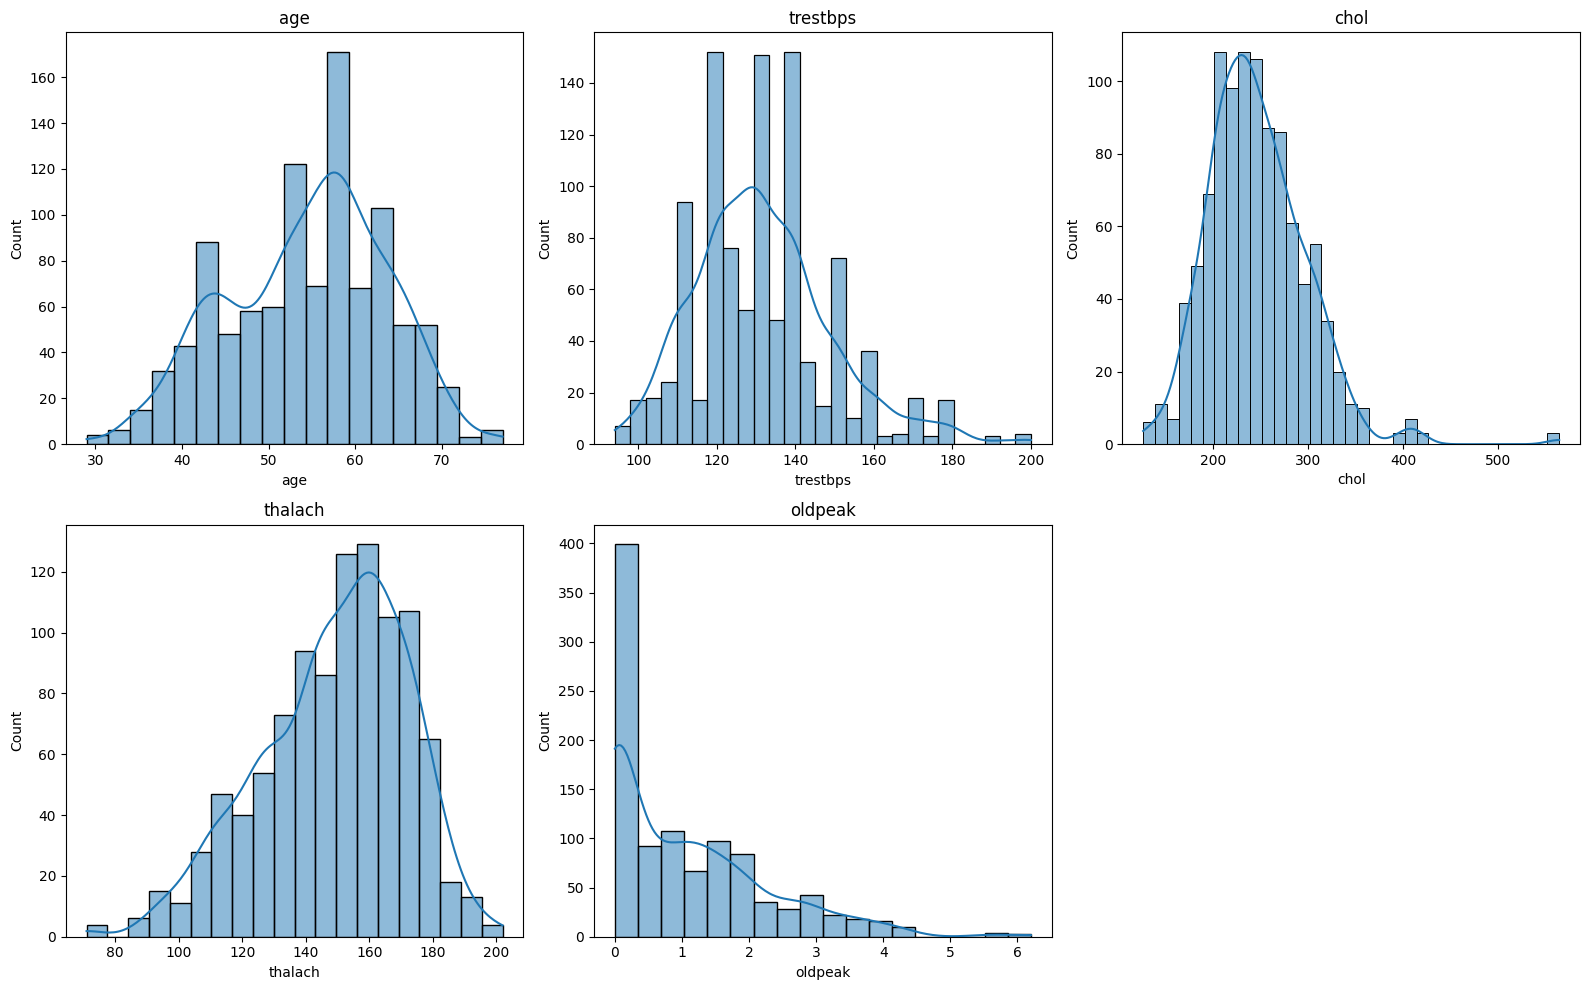

In [80]:
plt.figure(figsize = (16, 10))
i = 1
for column in num_cols:
  plt.subplot(2, 3, i)
  sns.histplot(df_class[column], kde=True)
  plt.title(column)
  i += 1
plt.tight_layout()
plt.show()

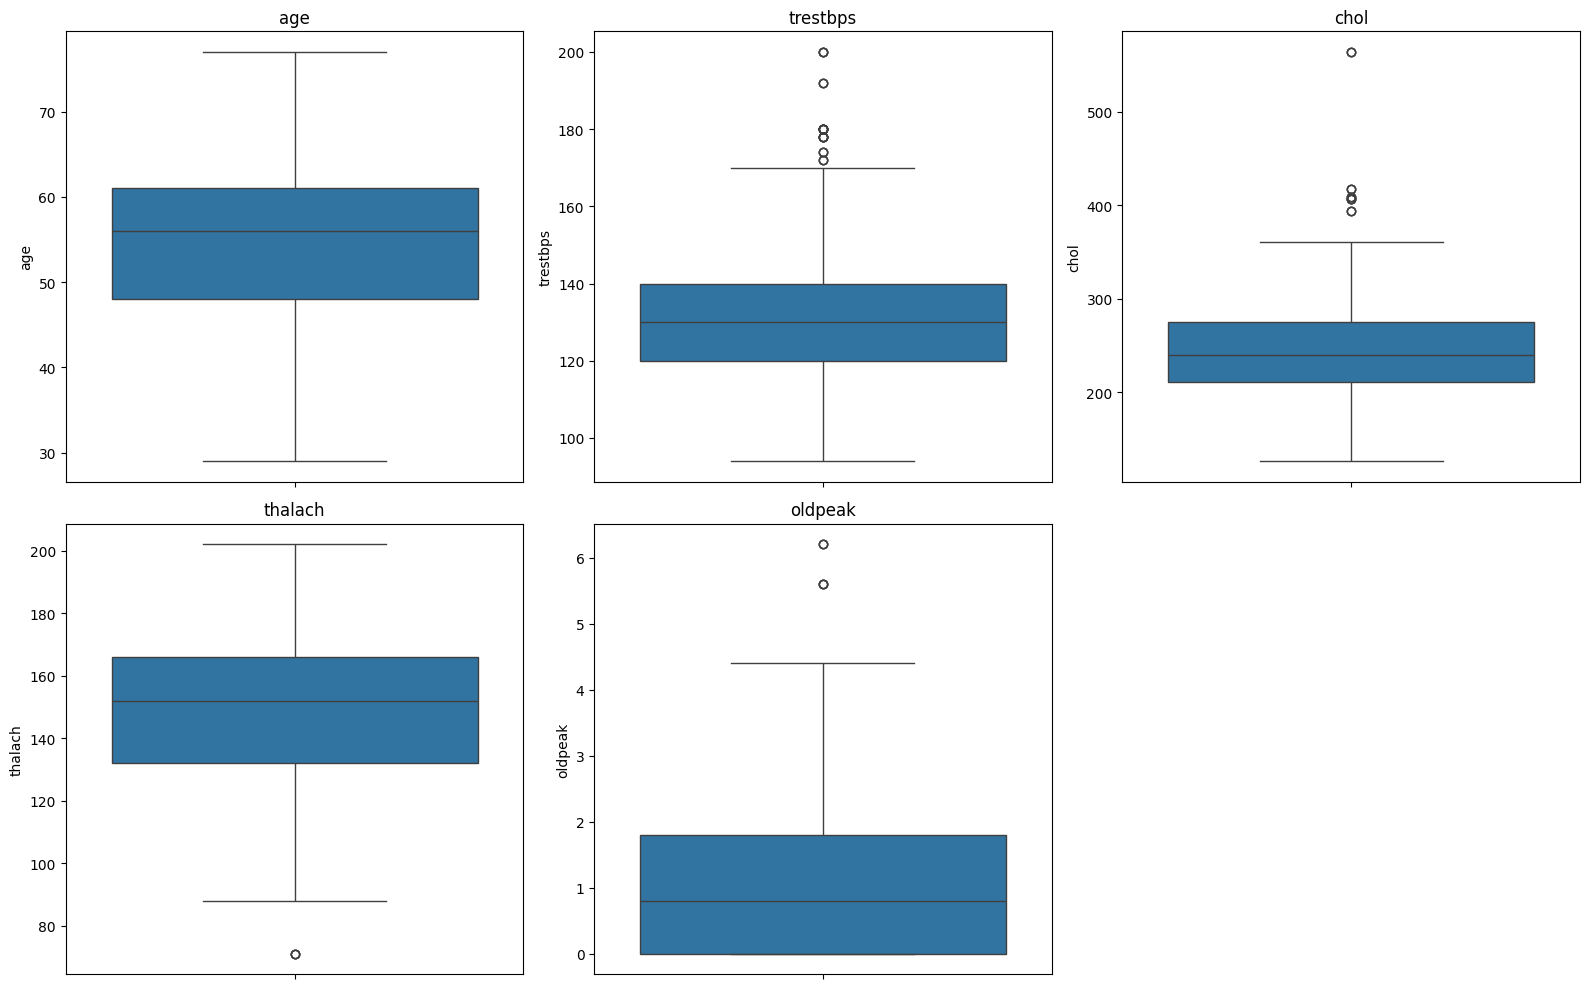

In [81]:
plt.figure(figsize = (16, 10))
i = 1
for column in num_cols:
  plt.subplot(2, 3, i)
  sns.boxplot(df_class[column])
  plt.title(column)
  i += 1
plt.tight_layout()
plt.show()

In [82]:
# Checing the outliers with IQR

# chol
Q1 = df_class['chol'].quantile(0.25)
Q3 = df_class['chol'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# viewing outliers (upper)
outliers_chol = df_class[(df_class['chol'] > upper)]
outliers_chol

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
123,65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
158,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
179,56,0,0,134,409,0,0,150,1,1.9,1,2,3,0
192,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
255,62,0,0,140,394,0,0,157,0,1.2,1,0,2,1
450,63,0,0,150,407,0,0,154,0,4.0,1,3,3,0
464,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
481,63,0,0,150,407,0,0,154,0,4.0,1,3,3,0
542,62,0,0,140,394,0,0,157,0,1.2,1,0,2,1
578,62,0,0,140,394,0,0,157,0,1.2,1,0,2,1


In [83]:
# trestbps
Q1 = df_class['trestbps'].quantile(0.25)
Q3 = df_class['trestbps'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# viewing outliers (upper)
outliers_trestbps = df_class[(df_class['trestbps'] > upper)]
outliers_trestbps

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
29,55,0,0,180,327,0,2,117,1,3.4,1,0,2,0
47,66,0,0,178,228,1,1,165,1,1.0,1,2,3,0
87,59,0,0,174,249,0,1,143,1,0.0,1,0,2,0
137,64,0,0,180,325,0,1,154,1,0.0,2,0,2,1
151,54,1,1,192,283,0,0,195,0,0.0,2,1,3,0
175,56,0,0,200,288,1,0,133,1,4.0,0,2,3,0
229,66,0,0,178,228,1,1,165,1,1.0,1,2,3,0
246,54,1,1,192,283,0,0,195,0,0.0,2,1,3,0
257,64,0,0,180,325,0,1,154,1,0.0,2,0,2,1
294,56,0,0,200,288,1,0,133,1,4.0,0,2,3,0


In [84]:
# Inference:
'''
1. 'trestbps' (Resting Blood Pressure)
    Few high-value outliers. But, these values (172–200 mmHg) represent clinically plausible cases of hypertension
    Therefore, the outliers were retained.

2. 'chol' (Serum Cholesterol)
    Contains several high-value outliers as detected by the IQR method.
    The observed values (394–564 mg/dL) are medically possible
    no outlier treatment was applied

3. 'thalach' (Maximum Heart Rate Achieved)
    Few outliers were detected.
    These values fall within physiologically possible limits
    Thus, the outliers were retained

4. 'oldpeak' (ST Depression Induced by Exercise)
    Few high-value outliers due to its right-skewed distribution.
    These values indicate greater ST depression, which is clinically meaningful
    As they represent valid observations rather than anomalies, no outlier handling was performed
'''

"\n1. 'trestbps' (Resting Blood Pressure)\n    Few high-value outliers. But, these values (172–200 mmHg) represent clinically plausible cases of hypertension\n    Therefore, the outliers were retained.\n\n2. 'chol' (Serum Cholesterol)\n    Contains several high-value outliers as detected by the IQR method.\n    The observed values (394–564 mg/dL) are medically possible\n    no outlier treatment was applied\n\n3. 'thalach' (Maximum Heart Rate Achieved)\n    Few outliers were detected.\n    These values fall within physiologically possible limits\n    Thus, the outliers were retained\n\n4. 'oldpeak' (ST Depression Induced by Exercise)\n    Few high-value outliers due to its right-skewed distribution.\n    These values indicate greater ST depression, which is clinically meaningful\n    As they represent valid observations rather than anomalies, no outlier handling was performed\n"

## Encoding

In [85]:
df_class.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [86]:
# cols to be one-hot encoded are:
ohe_cols = ['cp', 'restecg', 'thal']

# binary feature cols are already encoded -> 'sex', 'fbs' and 'exang'
# ordinal col 'slope' -> already encoded

In [87]:
# Initialize encoder
ohe_obj = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Encode
encoded = ohe_obj.fit_transform(df_class[ohe_cols])

# Create DataFrame with encoded column names
encoded_df = pd.DataFrame(
    encoded,
    columns = ohe_obj.get_feature_names_out(ohe_cols),
    index=df_class.index
)

# Drop original columns and concatenate encoded columns
df_class = pd.concat([df_class.drop(columns = ohe_cols), encoded_df], axis=1)

# After encoding
df_class.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,2,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,53,1,140,203,1,155,1,3.1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,145,174,0,125,1,2.6,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,61,1,148,203,0,161,0,0.0,2,1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,62,0,138,294,1,106,0,1.9,1,3,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [88]:
df_class.shape

(1025, 19)

## Scaling

In [89]:
# cols to be scaled are:
scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [90]:
# Initialize scaler
scaler = StandardScaler()

# Scale the selected columns
df_class[scale_cols] = scaler.fit_transform(df_class[scale_cols])

# Display the first few rows, after both scaling and encoding
df_class.head(20)

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,-0.268437,1,-0.377636,-0.659332,0,0.821321,0,-0.060888,2,2,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.158157,1,0.479107,-0.833861,1,0.255968,1,1.727137,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.716595,1,0.764688,-1.396233,0,-1.048692,1,1.301417,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.724079,1,0.936037,-0.833861,0,0.516900,0,-0.912329,2,1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.834359,0,0.364875,0.930822,1,-1.874977,0,0.705408,1,3,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5,0.393241,0,-1.805540,0.038784,0,-1.179158,0,-0.060888,1,0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,0.393241,1,-1.005914,1.396233,0,-0.396362,0,2.834010,0,3,0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
7,0.062402,1,1.621431,0.833861,0,-0.178919,1,-0.231177,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8,-0.930114,1,-0.663216,0.058176,0,-0.222407,0,-0.231177,2,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9,-0.047877,1,-0.548984,0.775685,0,-1.440090,1,1.812281,1,2,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## TrainTestSplit

In [91]:
# Checking the class balance in target_col
class_counts = df_class[target_col].value_counts()
ratio = class_counts.max() / class_counts.min()
print(f"Imbalance Ratio = {ratio:.2f}")

# Thus, well-balanced target col, so random splitting will be okay

Imbalance Ratio = 1.05


In [92]:
# After verifying that all cols are numeric

# Features and target
X = df_class.drop(columns = target_col)     # target_col = 'target'
y = df_class[target_col]

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (820, 18)
X_test : (205, 18)
y_train: (820,)
y_test : (205,)


## Logistic Regression

In [93]:
# Initialize model using object
log_reg = LogisticRegression(random_state=42)

# Train
log_reg.fit(X_train, y_train)

# Predict
y_pred_log_reg = log_reg.predict(X_test)

In [94]:
# Evaluation Metrics:

# Accuracy
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)

# Precision
pres_log_reg = precision_score(y_test, y_pred_log_reg)

# Recall
rec_log_reg = recall_score(y_test, y_pred_log_reg)

# F1-Score
f1_log_reg = f1_score(y_test, y_pred_log_reg)

## KNN

In [95]:
# Initialize model
knn = KNeighborsClassifier(n_neighbors=5)

# Train
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

In [96]:
# Evaluation Metrics:

# Accuracy
acc_knn = accuracy_score(y_test, y_pred_knn)

# Precision
pres_knn = precision_score(y_test, y_pred_knn)

# Recall
rec_knn = recall_score(y_test, y_pred_knn)

# F1-Score
f1_knn = f1_score(y_test, y_pred_knn)

## Random Forest

In [97]:
# Initialize model
rf_class = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf_class.fit(X_train, y_train)

# Predict
y_pred_rf_class = rf_class.predict(X_test)

In [98]:
# Evaluation Metrics:

# Accuracy
acc_rf_class = accuracy_score(y_test, y_pred_rf_class)

# Precision
pres_rf_class = precision_score(y_test, y_pred_rf_class)

# Recall
rec_rf_class = recall_score(y_test, y_pred_rf_class)

# F1-Score
f1_rf_class = f1_score(y_test, y_pred_rf_class)

## Evaluation Metrics:

In [99]:
print("CLASSIFICATION ALGORITHMS EVALUATION METRICS: \n")

print("Logistic Regression Performance")
print("Accuracy :", acc_log_reg)
print("Precision:", pres_log_reg)
print("Recall   :", rec_log_reg)
print("F1-Score :", f1_log_reg)

print("********************************************* \n")

print("KNN Performance \n")
print("Accuracy :", acc_knn)
print("Precision:", pres_knn)
print("Recall   :", rec_knn)
print("F1-Score :", f1_knn)

print("********************************************* \n")

print("Random Forest Performance \n")
print("Accuracy :", acc_rf_class)
print("Precision:", pres_rf_class)
print("Recall   :", rec_rf_class)
print("F1-Score :", f1_rf_class)

CLASSIFICATION ALGORITHMS EVALUATION METRICS: 

Logistic Regression Performance
Accuracy : 0.8
Precision: 0.7583333333333333
Recall   : 0.883495145631068
F1-Score : 0.8161434977578476
********************************************* 

KNN Performance 

Accuracy : 0.7853658536585366
Precision: 0.7706422018348624
Recall   : 0.8155339805825242
F1-Score : 0.7924528301886793
********************************************* 

Random Forest Performance 

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


In [ ]:
# Note: Recall is the key metric (When FN matter)
        # i.e., out of all the positive predictions, how many actually had heart disease (1)

# **Regression**

In [100]:
# For regression

num_cols = ['age', 'trestbps', 'thalach', 'oldpeak']
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal','target']

target_col =  'chol'      # shouldn't scale, nor handle any outliers
# It shows -> Serum cholesterol: Cholesterol level (in mg/dl)  => Regression